In [10]:
!pip install ipython-sql

In [12]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
conn = sqlite3.connect("northwind.db")

In [13]:
pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

,name
0,Categories
1,sqlite_sequence
2,CustomerCustomerDemo
3,CustomerDemographics
4,Customers
5,Employees
6,EmployeeTerritories
7,Order Details
8,Orders
9,Products


1. SQL Analysis

In [15]:
query = """
SELECT
    ProductName,
    SUM(Quantity) AS TotalSold
FROM "Order Details"
JOIN Products
ON Products.ProductID = "Order Details".ProductID
GROUP BY ProductName
ORDER BY TotalSold DESC
LIMIT 10;
"""

top_products = pd.read_sql(query, conn)
top_products

,ProductName,TotalSold
0,Louisiana Hot Spiced Okra,206213
1,Sir Rodney's Marmalade,205637
2,Teatime Chocolate Biscuits,205487
3,Sirop d'érable,205005
4,Gumbär Gummibärchen,204761
5,Outback Lager,204403
6,Ravioli Angelo,204251
7,Raclette Courdavault,204137
8,Uncle Bob's Organic Dried Pears,203970
9,Sasquatch Ale,203667


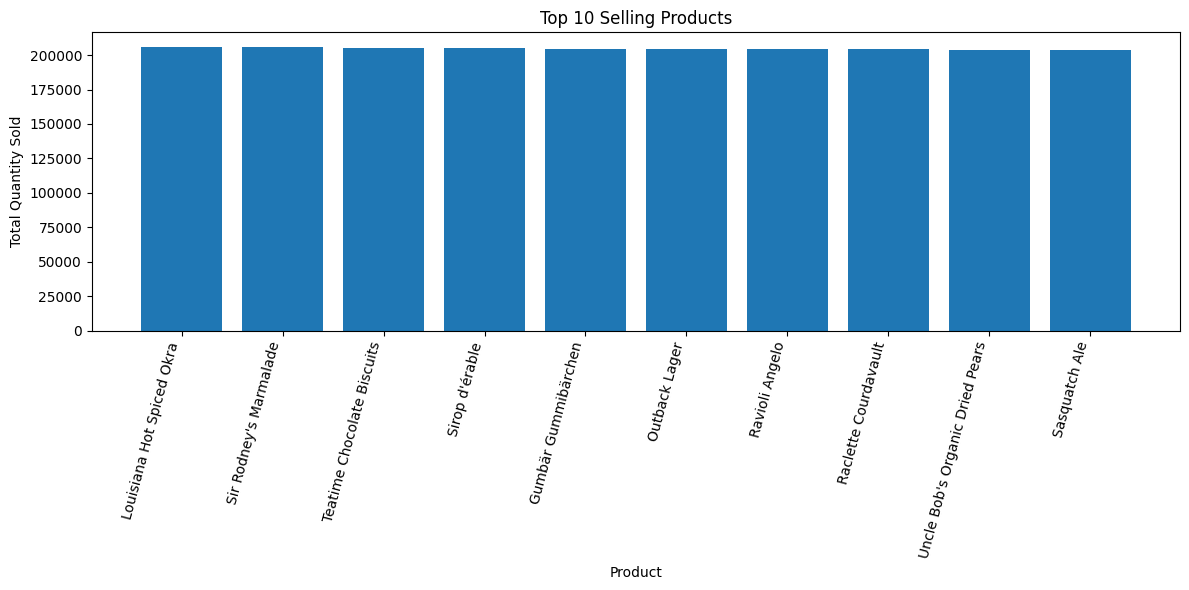

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(top_products["ProductName"], top_products["TotalSold"])

plt.xticks(rotation=75, ha='right')
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.title("Top 10 Selling Products")

plt.tight_layout()
plt.show()

## Top 10 Selling Products

This analysis identifies the ten best-selling products based on the total quantity sold.

### Observation

- Louisiana Hot Spiced Okra is the highest-selling product.
- The top ten products have relatively similar sales volumes.
- These products contribute significantly to overall business revenue and should be prioritized in inventory planning and marketing.

In [17]:
query = """
SELECT
    CompanyName,
    ROUND(SUM(UnitPrice * Quantity * (1 - Discount)),2) AS Revenue
FROM Customers
JOIN Orders
ON Customers.CustomerID = Orders.CustomerID
JOIN "Order Details"
ON Orders.OrderID = "Order Details".OrderID
GROUP BY CompanyName
ORDER BY Revenue DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query, conn)

top_customers

,CompanyName,Revenue
0,IT,9745371.29
1,B's Beverages,6154115.34
2,Hungry Coyote Import Store,5698023.67
3,Rancho grande,5559110.08
4,Gourmet Lanchonetes,5552309.81
5,Ana Trujillo Emparedados y helados,5534356.65
6,Ricardo Adocicados,5524517.31
7,Folies gourmandes,5505502.85
8,Let's Stop N Shop,5462198.02
9,LILA-Supermercado,5437438.34


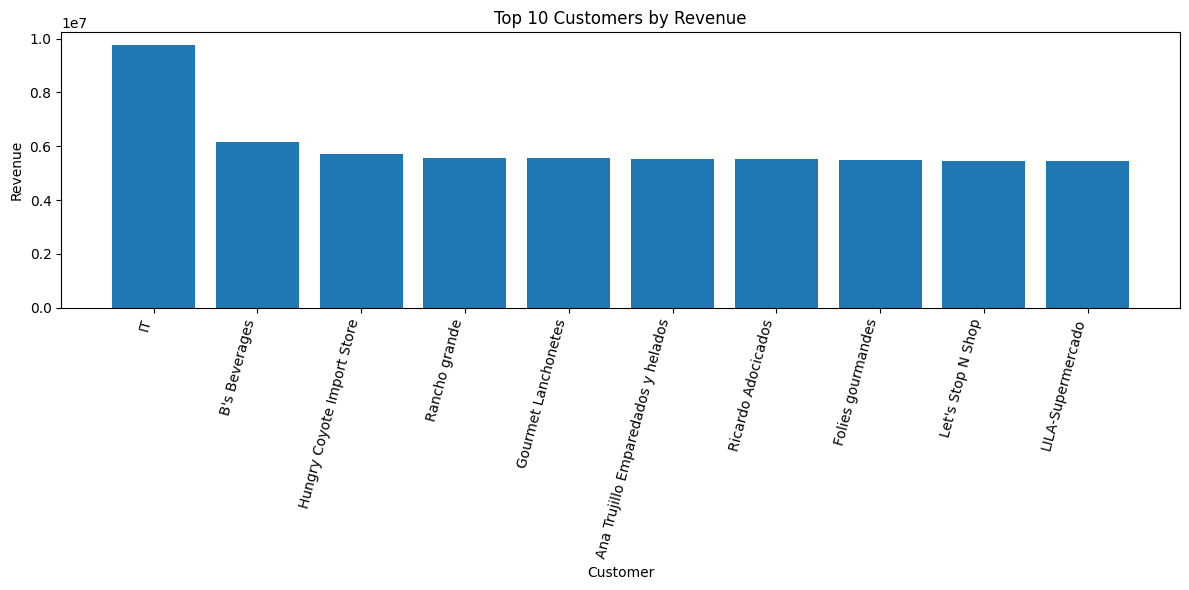

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(top_customers["CompanyName"], top_customers["Revenue"])

plt.xticks(rotation=75, ha='right')
plt.xlabel("Customer")
plt.ylabel("Revenue")
plt.title("Top 10 Customers by Revenue")

plt.tight_layout()
plt.show()

## Top 10 Customers by Revenue

This analysis identifies the customers who generated the highest revenue for the company.

### Observation

- **IT** is the highest revenue-generating customer.
- The top 10 customers contribute a significant portion of the company's total revenue.
- These customers could be prioritized for loyalty programs, personalized offers, and long-term business relationships.

In [19]:
query = """
SELECT
    strftime('%Y-%m', OrderDate) AS Month,
    ROUND(SUM(UnitPrice * Quantity * (1 - Discount)),2) AS Sales
FROM Orders
JOIN "Order Details"
ON Orders.OrderID = "Order Details".OrderID
GROUP BY Month
ORDER BY Month;
"""

monthly_sales = pd.read_sql(query, conn)

monthly_sales

,Month,Sales
0,2012-07,2066219.40
1,2012-08,3556875.79
2,2012-09,3440144.98
3,2012-10,3201529.96
4,2012-11,2980494.74
...,...,...
131,2023-06,3071787.73
132,2023-07,3350337.36
133,2023-08,3293158.67
134,2023-09,3544698.51


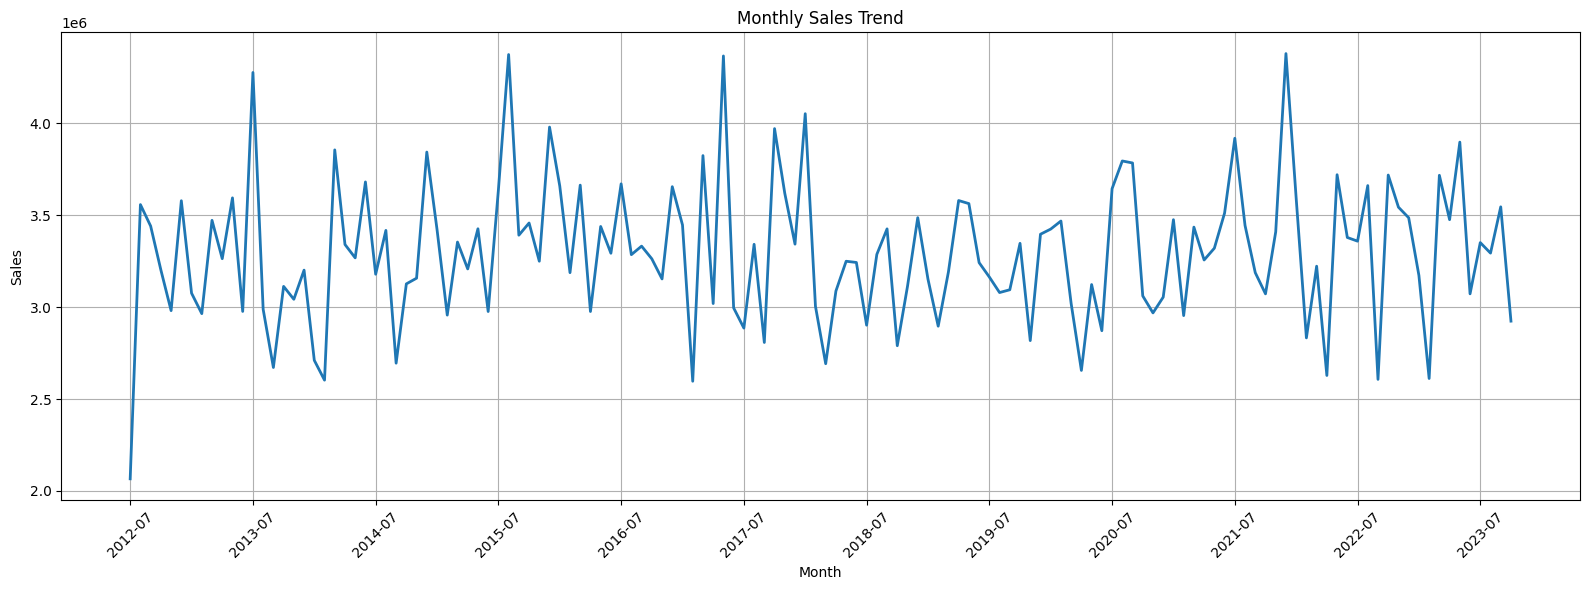

In [21]:
plt.figure(figsize=(16,6))

plt.plot(monthly_sales["Month"], monthly_sales["Sales"], linewidth=2)

# Show every 12th month (roughly one label per year)
plt.xticks(monthly_sales.index[::12], monthly_sales["Month"][::12], rotation=45)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")

plt.grid(True)
plt.tight_layout()

plt.show()

## Monthly Sales Trend

This visualization shows the monthly revenue generated over time.

### Observation

- Monthly sales fluctuate throughout the years.
- Several months recorded significant sales peaks.
- Understanding these trends can help businesses plan inventory, staffing, and marketing campaigns more effectively.

In [23]:
query = """
SELECT
    Categories.CategoryName,
    ROUND(
        SUM("Order Details".UnitPrice * "Order Details".Quantity * (1 - "Order Details".Discount)),
        2
    ) AS Revenue
FROM Categories
JOIN Products
    ON Categories.CategoryID = Products.CategoryID
JOIN "Order Details"
    ON Products.ProductID = "Order Details".ProductID
GROUP BY Categories.CategoryName
ORDER BY Revenue DESC;
"""

categories = pd.read_sql(query, conn)

categories

,CategoryName,Revenue
0,Beverages,92163184.18
1,Confections,66337803.07
2,Meat/Poultry,64881147.97
3,Dairy Products,58018116.79
4,Condiments,55795126.78
5,Seafood,49921604.17
6,Produce,32701119.88
7,Grains/Cereals,28568530.34


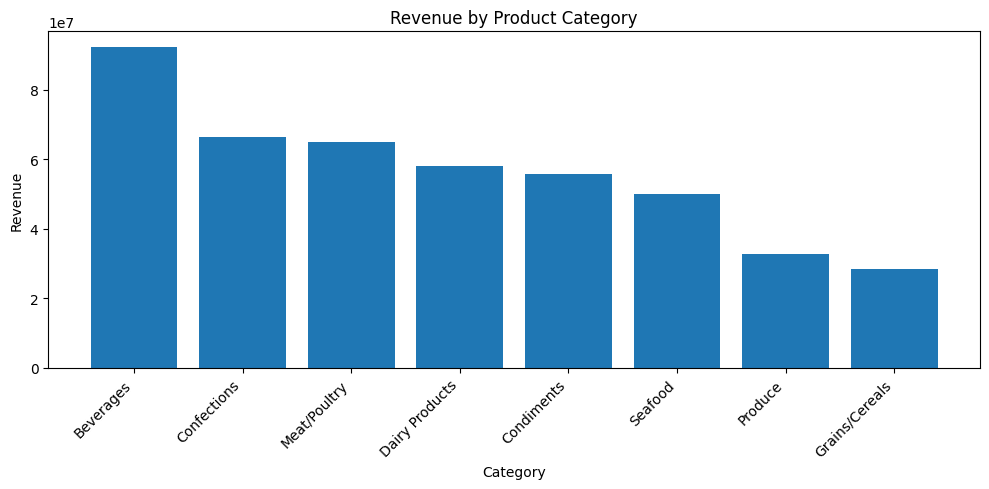

In [24]:
plt.figure(figsize=(10,5))

plt.bar(categories["CategoryName"], categories["Revenue"])

plt.xticks(rotation=45, ha="right")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.title("Revenue by Product Category")

plt.tight_layout()
plt.show()

In [25]:
query = """
SELECT
    Customers.CompanyName,
    COUNT(Orders.OrderID) AS PurchaseFrequency
FROM Customers
JOIN Orders
ON Customers.CustomerID = Orders.CustomerID
GROUP BY Customers.CompanyName
ORDER BY PurchaseFrequency DESC;
"""

purchase_frequency = pd.read_sql(query, conn)

purchase_frequency.head(10)

,CompanyName,PurchaseFrequency
0,IT,335
1,B's Beverages,210
2,Ricardo Adocicados,203
3,LILA-Supermercado,203
4,Gourmet Lanchonetes,202
5,Princesa Isabel Vinhos,200
6,Hungry Coyote Import Store,198
7,Tortuga Restaurante,197
8,Folies gourmandes,195
9,Ana Trujillo Emparedados y helados,195


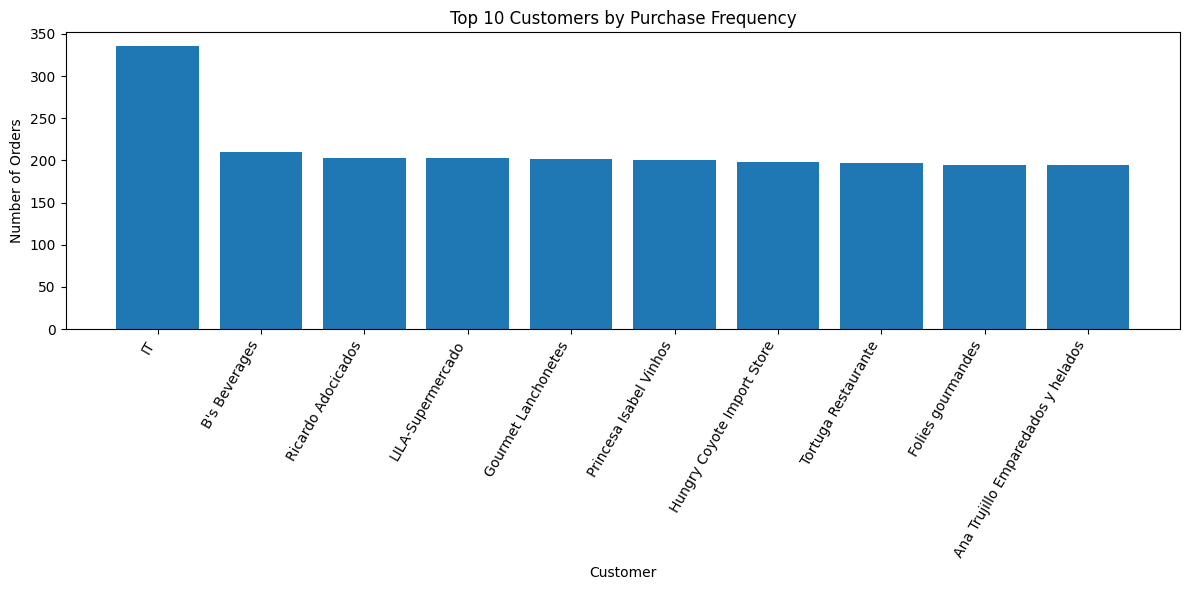

In [26]:
plt.figure(figsize=(12,6))

top10 = purchase_frequency.head(10)

plt.bar(top10["CompanyName"], top10["PurchaseFrequency"])

plt.xticks(rotation=60, ha="right")
plt.xlabel("Customer")
plt.ylabel("Number of Orders")
plt.title("Top 10 Customers by Purchase Frequency")

plt.tight_layout()
plt.show()

## Customer Purchase Frequency

This analysis identifies customers who place orders most frequently.

### Observation

- A few customers place significantly more orders than others.
- Frequent customers are valuable for long-term business growth.
- These customers are ideal candidates for loyalty and retention programs.

Final Business Insights:
# Business Insights

## 1. Top-selling products drive a significant portion of total sales.
These products should receive priority in inventory management and promotions.

## 2. A small group of customers contributes a large share of total revenue.
Maintaining strong relationships with these customers is crucial.

## 3. Sales fluctuate across different months.
Understanding seasonal trends can improve planning and forecasting.

## 4. Beverage products generate the highest revenue among all categories.
The company should continue investing in its strongest-performing categories.

## 5. Some customers purchase much more frequently than others.
Loyalty programs and personalized offers could increase customer retention and lifetime value.

# Conclusion

This project analyzed the Northwind database using SQL and Pandas to answer key business questions.

The analysis identified top-selling products, highest revenue-generating customers, monthly sales patterns, best-performing product categories, and customer purchase frequency.

These insights can help businesses make informed decisions related to inventory management, customer retention, sales strategy, and future business planning.

This assignment also strengthened practical skills in SQL querying, data manipulation with Pandas, data visualization, and business insight generation.